In [24]:
# Core imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path


In [25]:

from pathlib import Path
import pandas as pd

# Detect project root safely
CWD = Path.cwd()

if (CWD / "data").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data").exists():
    PROJECT_ROOT = CWD.parent
else:
    raise RuntimeError("Could not locate project root containing /data directory")

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

processed_csv = DATA_DIR / "uniswap_v3_usdc_weth_swaps_processed.csv"
if_csv = RESULTS_DIR / "isolation_forest_results.csv"
ae_csv = RESULTS_DIR / "autoencoder_results.csv"

def assert_exists(p: Path):
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")

for p in [processed_csv, if_csv, ae_csv]:
    assert_exists(p)

# Load data
df = pd.read_csv(processed_csv)
if_res = pd.read_csv(if_csv)
ae_res = pd.read_csv(ae_csv)

print("Project root :", PROJECT_ROOT)
print("Processed df :", df.shape)
print("IF results  :", if_res.shape)
print("AE results  :", ae_res.shape)

df.head(2)


Project root : c:\Users\aycag\OneDrive\Masaüstü\Visual Studio Codes\Python Codes\Blockchain-Smart-Contract-Transaction-Anomaly-Detection-Project
Processed df : (1000, 21)
IF results  : (1000, 3)
AE results  : (1000, 6)


,address,topics,data,blockNumber,blockHash,timeStamp,gasPrice,gasUsed,logIndex,transactionHash,...,blockNumber_int,timeStamp_int,timeStamp_dt,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
0,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,['0xc42079f94a6350d7e6235f29174924f928cc2ac818...,0xffffffffffffffffffffffffffffffffffffffffffff...,0x112a881,0xd5ca78be6c6b42cf929074f502cef676372c26f8d0ba...,0x64ea269b,0x59357e7b1,0x3559a,0xbd,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,...,18000001,1693066907,2023-08-26 16:21:47,0xdef1c0ded9bec7f1a1670819833240f027b25eff,0xb4eae88d1643e172518dde0ef213c20628798c65,-112691264,68325951804594637,1950377674162784547402475521943836,42650691009184698025,202234
1,0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640,['0xc42079f94a6350d7e6235f29174924f928cc2ac818...,0x00000000000000000000000000000000000000000000...,0x112a882,0x5b94c39ad7eecbf043f62a4a76c5abee87195207df98...,0x64ea26a7,0x5760a9dc4,0x377b4,0xad,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,...,18000002,1693066919,2023-08-26 16:21:59,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0xa66cdad5facbcbf74d9b60dcc8034c2a485e63ff,1075000000,-651132330540292128,1950376464615720204913290619496759,42650691009184698025,202234


In [26]:

# Use transactionHash as the join key (created in earlier notebooks)
merged = df.merge(if_res, on="transactionHash", how="inner").merge(ae_res, on="transactionHash", how="inner")

# Standardize anomaly flags
merged["if_is_anomaly"] = (merged["isolation_forest_anomaly"] == -1)
merged["ae_is_anomaly"] = (merged["ae_anomaly"] == -1)

print("Merged shape:", merged.shape)
print("IF anomaly rate:", merged["if_is_anomaly"].mean())
print("AE anomaly rate:", merged["ae_is_anomaly"].mean())

merged[[
    "transactionHash", "if_is_anomaly", "ae_is_anomaly",
    "isolation_score", "ae_reconstruction_error"
]].head()


Merged shape: (1090, 30)
IF anomaly rate: 0.06788990825688074
AE anomaly rate: 0.07339449541284404


,transactionHash,if_is_anomaly,ae_is_anomaly,isolation_score,ae_reconstruction_error
0,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,True,True,0.003867,2.420245
1,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,True,False,0.004458,2.238784
2,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,True,False,0.003402,1.353680
3,0x070379239598fdeaed5cf8910f87135c55783fb75778...,False,False,-0.010391,1.298518
4,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,True,False,0.005050,1.440844


In [27]:
# Overlap / agreement summary
n = len(merged)
if_only = (merged["if_is_anomaly"] & ~merged["ae_is_anomaly"]).sum()
ae_only = (~merged["if_is_anomaly"] & merged["ae_is_anomaly"]).sum()
both = (merged["if_is_anomaly"] & merged["ae_is_anomaly"]).sum()
neither = (~merged["if_is_anomaly"] & ~merged["ae_is_anomaly"]).sum()

agreement = (both + neither) / n

summary = pd.DataFrame({
    "count": [if_only, ae_only, both, neither],
    "share": [if_only/n, ae_only/n, both/n, neither/n],
}, index=["IF only", "AE only", "Both", "Neither"])

print("Agreement rate:", round(agreement, 4))
summary


Agreement rate: 0.967


,count,share
IF only,15,0.013761
AE only,21,0.019266
Both,59,0.054128
Neither,995,0.912844


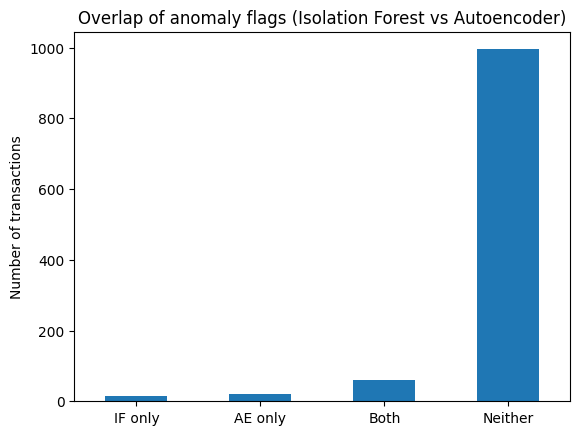

In [28]:
# Simple bar plot for overlap
plt.figure()
summary["count"].plot(kind="bar")
plt.title("Overlap of anomaly flags (Isolation Forest vs Autoencoder)")
plt.ylabel("Number of transactions")
plt.xticks(rotation=0)
plt.show()


In [29]:
def minmax(x: pd.Series) -> pd.Series:
    x = x.astype(float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

# IF: convert to "higher = more anomalous"
# If your IF score is decision_function-like (higher=more normal), invert it.
# We detect direction by comparing mean score of anomalies vs normals.
if_mean_anom = merged.loc[merged["if_is_anomaly"], "isolation_score"].mean()
if_mean_norm = merged.loc[~merged["if_is_anomaly"], "isolation_score"].mean()

if_higher_is_normal = (if_mean_norm > if_mean_anom)

merged["if_anom_score_raw"] = (-merged["isolation_score"]) if if_higher_is_normal else merged["isolation_score"]
merged["if_anom_score"] = minmax(merged["if_anom_score_raw"])

# AE: higher recon error = more anomalous
merged["ae_anom_score"] = minmax(merged["ae_reconstruction_error"])

print("IF higher-is-normal detected?:", if_higher_is_normal)
merged[["if_anom_score", "ae_anom_score"]].describe()


IF higher-is-normal detected?: False


,if_anom_score,ae_anom_score
count,1090.000000,1090.000000
mean,0.145889,0.011357
std,0.167927,0.063932
min,0.000000,0.000000
25%,0.042240,0.000025
50%,0.087729,0.000067
75%,0.146637,0.000160
max,1.000000,1.000000


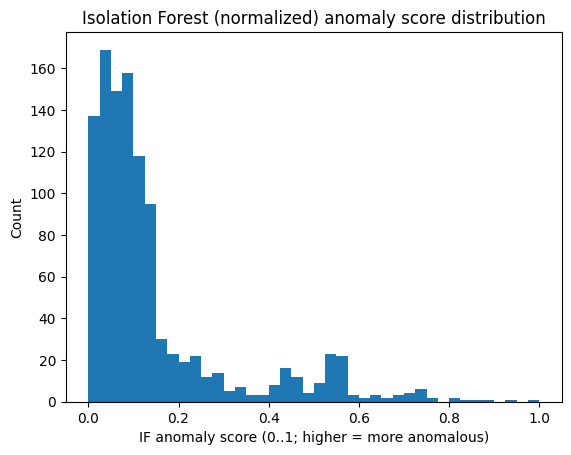

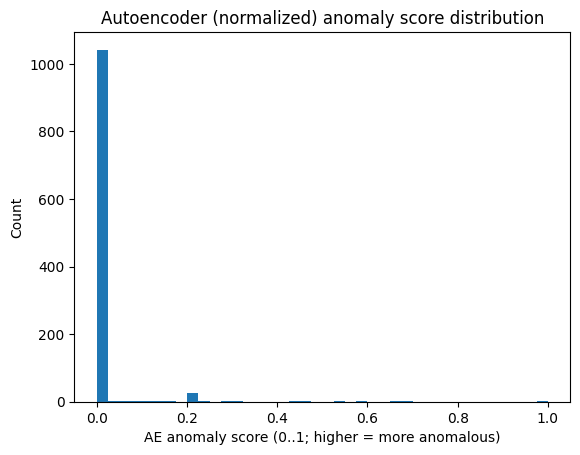

In [30]:
# Score distributions
plt.figure()
plt.hist(merged["if_anom_score"], bins=40)
plt.title("Isolation Forest (normalized) anomaly score distribution")
plt.xlabel("IF anomaly score (0..1; higher = more anomalous)")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(merged["ae_anom_score"], bins=40)
plt.title("Autoencoder (normalized) anomaly score distribution")
plt.xlabel("AE anomaly score (0..1; higher = more anomalous)")
plt.ylabel("Count")
plt.show()


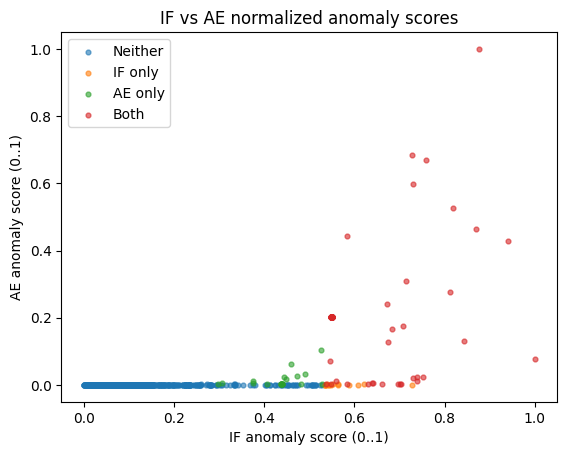

In [31]:
# Categorize points by agreement for visualization
def label_category(r):
    if r["if_is_anomaly"] and r["ae_is_anomaly"]:
        return "Both"
    if r["if_is_anomaly"] and not r["ae_is_anomaly"]:
        return "IF only"
    if (not r["if_is_anomaly"]) and r["ae_is_anomaly"]:
        return "AE only"
    return "Neither"

merged["agreement_category"] = merged.apply(label_category, axis=1)

plt.figure()
for cat in ["Neither", "IF only", "AE only", "Both"]:
    sub = merged[merged["agreement_category"] == cat]
    plt.scatter(sub["if_anom_score"], sub["ae_anom_score"], s=12, alpha=0.6, label=cat)

plt.title("IF vs AE normalized anomaly scores")
plt.xlabel("IF anomaly score (0..1)")
plt.ylabel("AE anomaly score (0..1)")
plt.legend()
plt.show()


In [32]:
# Union and intersection labels
merged["fusion_union_anom"] = merged["if_is_anomaly"] | merged["ae_is_anomaly"]
merged["fusion_intersection_anom"] = merged["if_is_anomaly"] & merged["ae_is_anomaly"]

# Score ensemble
w_if, w_ae = 0.5, 0.5
merged["fusion_score"] = w_if * merged["if_anom_score"] + w_ae * merged["ae_anom_score"]

# Choose a target anomaly rate (average of the two model rates)
target_rate = float((merged["if_is_anomaly"].mean() + merged["ae_is_anomaly"].mean()) / 2)
threshold = float(np.quantile(merged["fusion_score"], 1 - target_rate))

merged["fusion_ensemble_anom"] = merged["fusion_score"] >= threshold

print("Target anomaly rate:", round(target_rate, 4))
print("Chosen fusion threshold (quantile):", round(threshold, 6))
print("Ensemble anomaly rate:", round(merged["fusion_ensemble_anom"].mean(), 4))


Target anomaly rate: 0.0706
Chosen fusion threshold (quantile): 0.262697
Ensemble anomaly rate: 0.0706


In [33]:
# Compare anomaly counts across methods
fusion_counts = pd.DataFrame({
    "IF": merged["if_is_anomaly"].value_counts(),
    "AE": merged["ae_is_anomaly"].value_counts(),
    "Union": merged["fusion_union_anom"].value_counts(),
    "Intersection": merged["fusion_intersection_anom"].value_counts(),
    "Ensemble": merged["fusion_ensemble_anom"].value_counts(),
}).fillna(0).astype(int)

fusion_counts


,IF,AE,Union,Intersection,Ensemble
False,1016,1010,995,1031,1013
True,74,80,95,59,77


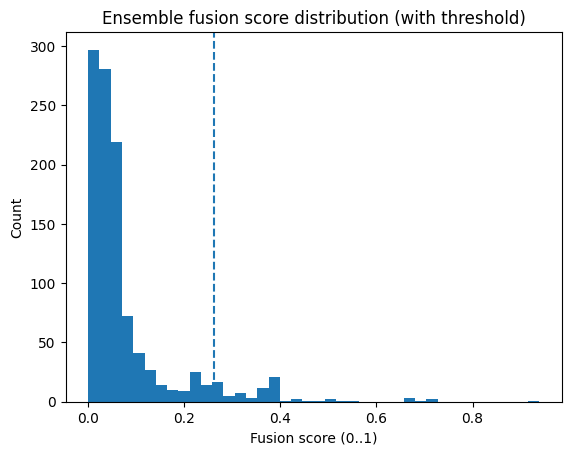

In [34]:
# Fusion score distribution + threshold
plt.figure()
plt.hist(merged["fusion_score"], bins=40)
plt.axvline(threshold, linestyle="--")
plt.title("Ensemble fusion score distribution (with threshold)")
plt.xlabel("Fusion score (0..1)")
plt.ylabel("Count")
plt.show()


In [35]:
# Choose which fusion label will be used for final insights
FUSION_COL = "fusion_ensemble_anom"  # change to fusion_union_anom / fusion_intersection_anom if needed

anom = merged[merged[FUSION_COL]].copy()
norm = merged[~merged[FUSION_COL]].copy()

print("Final fused anomalies:", len(anom))
print("Final fused normals  :", len(norm))
anom[["transactionHash", "fusion_score"]].head()


Final fused anomalies: 77
Final fused normals  : 1013


,transactionHash,fusion_score
0,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,0.269649
1,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,0.270285
2,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,0.268746
4,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,0.270716
7,0x195b32039fe91b7d662827637e7fac59ebde269aa223...,0.274959


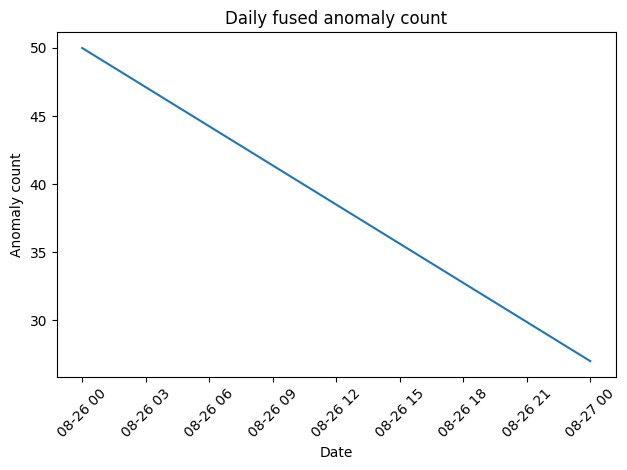

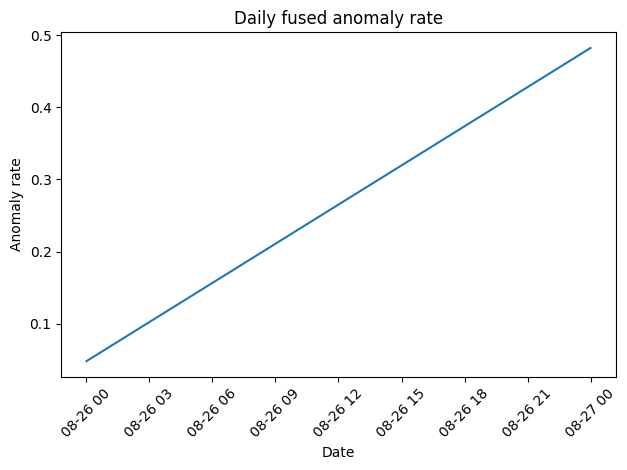

In [36]:
# Parse timestamp to datetime if present
if "timeStamp_dt" in merged.columns:
    merged["timeStamp_dt"] = pd.to_datetime(merged["timeStamp_dt"], errors="coerce")
    merged["date"] = merged["timeStamp_dt"].dt.date
elif "timeStamp_int" in merged.columns:
    merged["timeStamp_dt"] = pd.to_datetime(merged["timeStamp_int"], unit="s", errors="coerce")
    merged["date"] = merged["timeStamp_dt"].dt.date
else:
    merged["date"] = None

if merged["date"].notna().any():
    daily = merged.groupby("date")[FUSION_COL].agg(["count", "sum"]).rename(columns={"sum":"anomaly_count"})
    daily["anomaly_rate"] = daily["anomaly_count"] / daily["count"]

    plt.figure()
    plt.plot(daily.index, daily["anomaly_count"])
    plt.title("Daily fused anomaly count")
    plt.xlabel("Date")
    plt.ylabel("Anomaly count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.plot(daily.index, daily["anomaly_rate"])
    plt.title("Daily fused anomaly rate")
    plt.xlabel("Date")
    plt.ylabel("Anomaly rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    daily.tail()
else:
    print("No timestamp column found for temporal plots.")


In [37]:
# Pick candidate numeric columns if they exist
candidate_cols = [
    "amount0", "amount1", "liquidity", "tick", "sqrtPriceX96",
    "gasUsed", "gasPrice", "logIndex", "transactionIndex"
]
num_cols = [c for c in candidate_cols if c in merged.columns]

if not num_cols:
    print("No expected numeric columns found for feature comparison.")
else:
    comp = pd.DataFrame({
        "median_normal": norm[num_cols].median(numeric_only=True),
        "median_anom": anom[num_cols].median(numeric_only=True),
        "mean_normal": norm[num_cols].mean(numeric_only=True),
        "mean_anom": anom[num_cols].mean(numeric_only=True),
    })

    # robust relative change: (anom - normal) / (|normal| + eps)
    eps = 1e-12
    comp["median_rel_change"] = (comp["median_anom"] - comp["median_normal"]) / (comp["median_normal"].abs() + eps)

    # sort by absolute relative change to highlight strongest drivers
    comp = comp.sort_values("median_rel_change", key=lambda s: s.abs(), ascending=False)

    comp


C:\Users\aycag\AppData\Local\Temp\ipykernel_41060\2465379437.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm[feat].dropna().values, anom[feat].dropna().values], labels=["Normal", "Fused Anomaly"])


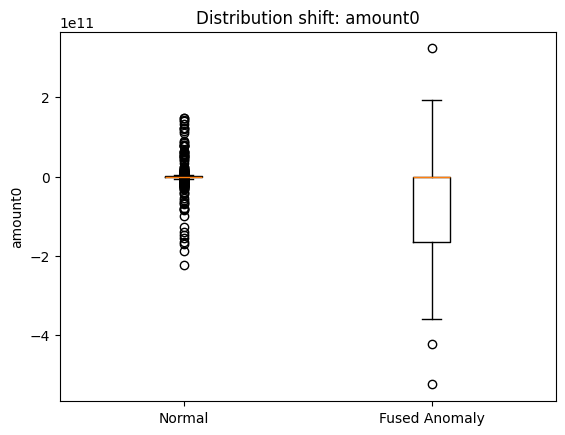

C:\Users\aycag\AppData\Local\Temp\ipykernel_41060\2465379437.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([norm[feat].dropna().values, anom[feat].dropna().values], labels=["Normal", "Fused Anomaly"])


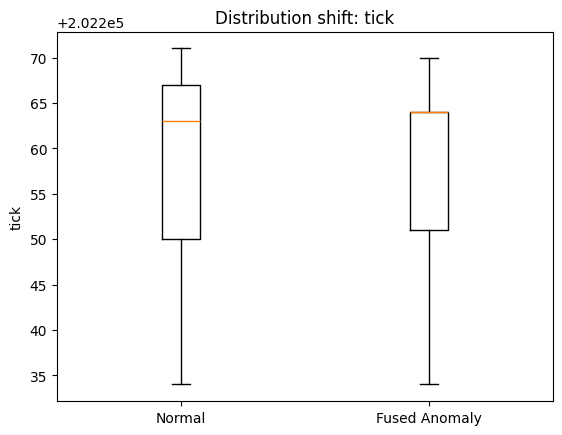

In [38]:
# Boxplots for the top 6 most shifted features (if available)
if num_cols:
    top_feats = list(comp.index[:6])
    for feat in top_feats:
        plt.figure()
        plt.boxplot([norm[feat].dropna().values, anom[feat].dropna().values], labels=["Normal", "Fused Anomaly"])
        plt.title(f"Distribution shift: {feat}")
        plt.ylabel(feat)
        plt.show()


sender
0xe592427a0aece92de3edee1f18e0157c05861564    31
0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    18
0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    15
0xdef1c0ded9bec7f1a1670819833240f027b25eff     3
0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
0xbc2c6cd5013585ac720160efcb1feced30837177     2
0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0     2
0xcb3702bc25b0f284b032e5edf1a1ebea2fe43255     1
0x00fc00900000002c00be4ef8f49c000211000c43     1
0xa69babef1ca67a37ffaf7a485dfff3382056e78c     1
Name: count, dtype: int64

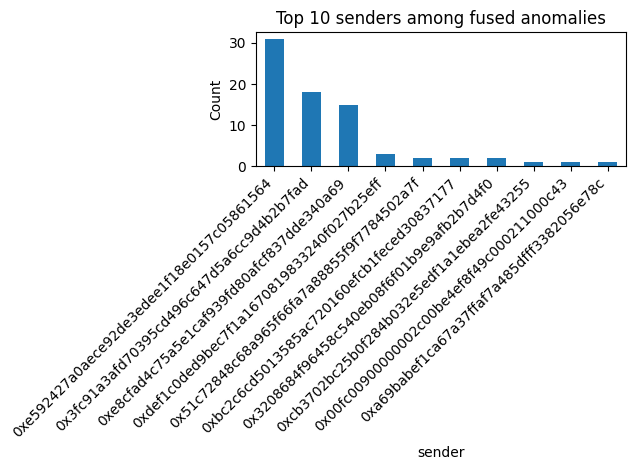

recipient
0x638a98bbb92a7582d07c52ff407d49664dc8b3ee    27
0xe8cfad4c75a5e1caf939fd80afcf837dde340a69    15
0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad    12
0xdef171fe48cf0115b1d80b88dc8eab59176fee57     3
0xbc2c6cd5013585ac720160efcb1feced30837177     2
0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0     2
0x51c72848c68a965f66fa7a88855f9f7784502a7f     2
0xa66cdad5facbcbf74d9b60dcc8034c2a485e63ff     1
0xb4eae88d1643e172518dde0ef213c20628798c65     1
0xcb3702bc25b0f284b032e5edf1a1ebea2fe43255     1
Name: count, dtype: int64

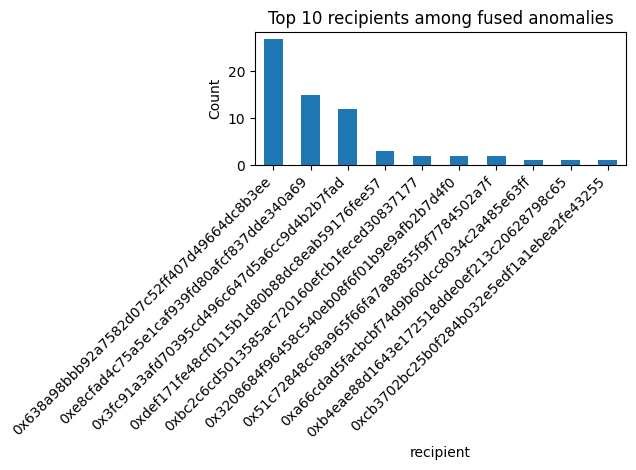

In [39]:
addr_cols = [c for c in ["sender", "recipient"] if c in merged.columns]

if not addr_cols:
    print("No sender/recipient columns found.")
else:
    for col in addr_cols:
        top = anom[col].value_counts().head(10)
        display(top)

        plt.figure()
        top.plot(kind="bar")
        plt.title(f"Top {len(top)} {col}s among fused anomalies")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


In [40]:
# Columns helpful for reporting (use only those present)
report_cols = [
    "transactionHash", "fusion_score",
    "isolation_score", "ae_reconstruction_error",
    "amount0", "amount1", "liquidity", "tick",
    "gasUsed", "gasPrice",
    "sender", "recipient",
    "timeStamp_dt", "blockNumber_int"
]
report_cols = [c for c in report_cols if c in merged.columns]

topK = 15
top_anom = anom.sort_values("fusion_score", ascending=False).head(topK)[report_cols].copy()
top_anom


,transactionHash,fusion_score,isolation_score,ae_reconstruction_error,amount0,amount1,liquidity,tick,gasUsed,gasPrice,sender,recipient,timeStamp_dt,blockNumber_int
967,0xa663daaf6615cc29397ad38f8fdfa3f7e7505c7f6a95...,0.938582,0.147927,1495.304396,-265430999843,161460000000000000000,834267773667859163307,202266,0x13853f,0x2a05c99b7,0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0,0x3208684f96458c540eb08f6f01b9e9afb2b7d4f0,2023-08-26 23:51:35,18002242
959,0x906c87dfc10add3947e88b32d7c8ab0982f93b77b6b7...,0.713825,0.097589,1000.525081,-223421442037,135900000000000000000,858490743562473777521,202266,0x41d73,0x267115769,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,2023-08-26 23:47:47,18002223
894,0x9f1645ae3f3d8f808e31755c5dd0f89d3b13a273e2e8...,0.705117,0.084263,1021.435996,-221943584509,135000000000000000000,802204927987842757523,202266,0x41d90,0x2c1e2c560,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,2023-08-26 23:17:35,18002072
37,0xd71237977566fc90f775c31715f7d443e46eb7e35672...,0.685282,0.175015,642.338974,-523931437876,318093935332575067681,36436129027849465614,202251,0x26f2a,0x97c6c186fc,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,2023-08-26 16:41:23,18000099
75,0x47923e680c5b276593275e006e6c32d51ff8198d8bab...,0.673294,0.123528,787.912601,100101107163,-60741857111288434426,1899816936058942905732,202252,0x70593,0x2e6a1c824,0xe592427a0aece92de3edee1f18e0157c05861564,0xdef171fe48cf0115b1d80b88dc8eab59176fee57,2023-08-26 16:58:11,18000183
955,0x4f19c6d7add8496b0f6c7816a20ec79f5fc1d223c4e6...,0.667818,0.145237,695.040299,-222018850285,135000000000000000000,1808145905707358708007,202262,0x4d55a,0x2a5742805,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,2023-08-26 23:43:59,18002204
907,0x55870b25aef8b72d74d421928862506efbf550c416c0...,0.663600,0.085051,894.502729,-209607817048,127500000000000000000,786091727607707560446,202266,0x49290,0x2f19e6ba4,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,2023-08-26 23:24:35,18002107
266,0x23b59448f8fc805b8f633bb15688af70b7290da9b8eb...,0.543489,0.119940,412.362454,117900149524,-71663468374902938570,529443323562593035056,202269,0x1b6dca,0x339fb2b1c,0xe592427a0aece92de3edee1f18e0157c05861564,0xdef171fe48cf0115b1d80b88dc8eab59176fee57,2023-08-26 18:33:47,18000659
16,0x525bde5f069dac2457e3dccda54bdbef9bf268a3ac95...,0.538807,0.200054,116.061900,-421800456347,255828679014122873255,42650691009184698025,202239,0x1f9c4,0x38e5e5d377,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,0xe8cfad4c75a5e1caf939fd80afcf837dde340a69,2023-08-26 16:34:35,18000065
890,0xa6ad3072341f593832ebe9875b95ad55239c76c91529...,0.513576,0.023677,662.103443,-246626742615,150000000000000000000,69023024792007499868,202266,0x3148c,0x2ef852eb4,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,0x3fc91a3afd70395cd496c647d5a6cc9d4b2b7fad,2023-08-26 23:15:47,18002063


In [41]:
out = merged[[
    "transactionHash",
    "if_is_anomaly", "ae_is_anomaly",
    "fusion_union_anom", "fusion_intersection_anom", "fusion_ensemble_anom",
    "if_anom_score", "ae_anom_score", "fusion_score"
]].copy()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_path = RESULTS_DIR / "fusion_results.csv"
out.to_csv(out_path, index=False)

print("Saved:", out_path.resolve())
out.head()


Saved: C:\Users\aycag\OneDrive\Masaüstü\Visual Studio Codes\Python Codes\Blockchain-Smart-Contract-Transaction-Anomaly-Detection-Project\results\fusion_results.csv


,transactionHash,if_is_anomaly,ae_is_anomaly,fusion_union_anom,fusion_intersection_anom,fusion_ensemble_anom,if_anom_score,ae_anom_score,fusion_score
0,0x8187139f2cf5e1d2b0a817f2951f0592fccc43dabf71...,True,True,True,True,True,0.537684,0.001614,0.269649
1,0x29ec08dc5eed0e1cd411b29c52607661155087ffa107...,True,False,True,False,True,0.539076,0.001493,0.270285
2,0xcf7b968094b30c7a7e1c88003e8496c621b73ef284e4...,True,False,True,False,True,0.536590,0.000901,0.268746
3,0x070379239598fdeaed5cf8910f87135c55783fb75778...,False,False,False,False,False,0.504085,0.000864,0.252475
4,0xb3bb64bb54d6465a80bfa0fe396868c08c40595b84e9...,True,False,True,False,True,0.540473,0.000959,0.270716


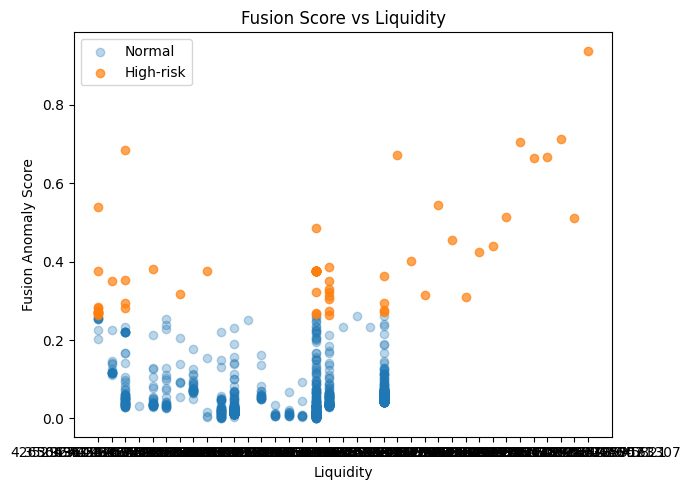

In [42]:
plt.figure(figsize=(7,5))
plt.scatter(norm["liquidity"], norm["fusion_score"], alpha=0.3, label="Normal")
plt.scatter(anom["liquidity"], anom["fusion_score"], alpha=0.7, label="High-risk")

plt.xlabel("Liquidity")
plt.ylabel("Fusion Anomaly Score")
plt.title("Fusion Score vs Liquidity")
plt.legend()
plt.tight_layout()
plt.show()


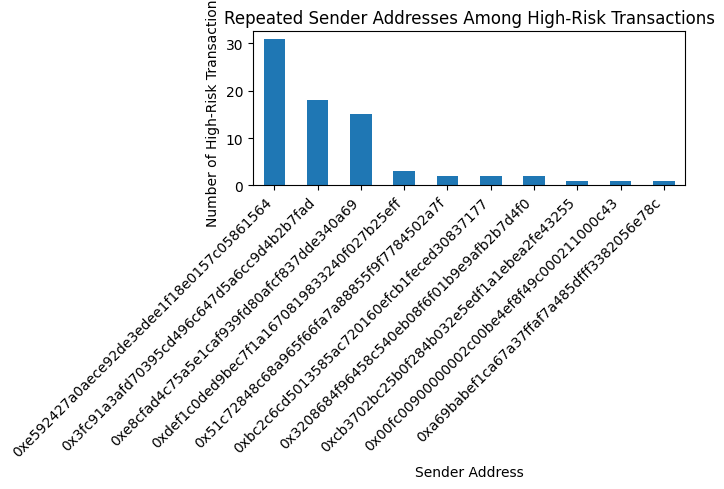

In [43]:
top_senders = anom["sender"].value_counts().head(10)

plt.figure(figsize=(7,5))
top_senders.plot(kind="bar")

plt.xlabel("Sender Address")
plt.ylabel("Number of High-Risk Transactions")
plt.title("Repeated Sender Addresses Among High-Risk Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


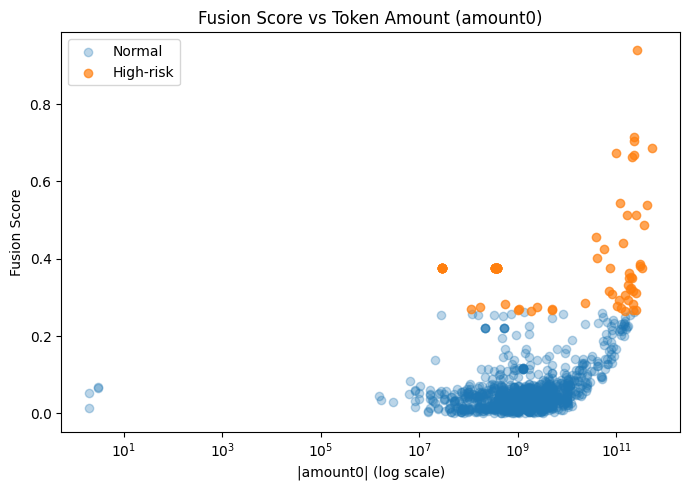

In [44]:
plt.figure(figsize=(7,5))
plt.scatter(
    np.abs(norm["amount0"]), norm["fusion_score"],
    alpha=0.3, label="Normal"
)
plt.scatter(
    np.abs(anom["amount0"]), anom["fusion_score"],
    alpha=0.7, label="High-risk"
)

plt.xscale("log")
plt.xlabel("|amount0| (log scale)")
plt.ylabel("Fusion Score")
plt.title("Fusion Score vs Token Amount (amount0)")
plt.legend()
plt.tight_layout()
plt.show()


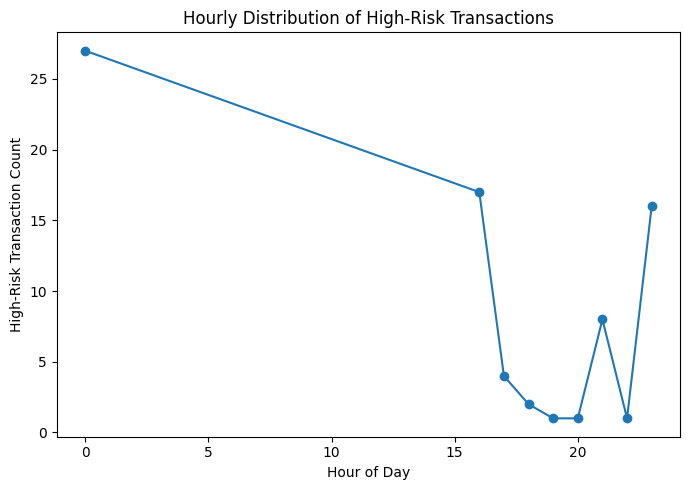

In [45]:
anom_time = anom.copy()

if "timeStamp_dt" in anom_time.columns:
    anom_time["timeStamp_dt"] = pd.to_datetime(anom_time["timeStamp_dt"], errors="coerce")
elif "timeStamp_int" in anom_time.columns:
    anom_time["timeStamp_dt"] = pd.to_datetime(
        anom_time["timeStamp_int"], unit="s", errors="coerce"
    )
else:
    raise ValueError("No timestamp column found")

anom_time["hour"] = anom_time["timeStamp_dt"].dt.hour

hourly_counts = anom_time["hour"].value_counts().sort_index()

plt.figure(figsize=(7,5))
hourly_counts.plot(kind="line", marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("High-Risk Transaction Count")
plt.title("Hourly Distribution of High-Risk Transactions")
plt.tight_layout()
plt.show()



In [46]:
vals_norm = pd.to_numeric(norm[f], errors="coerce").dropna()
vals_anom = pd.to_numeric(anom[f], errors="coerce").dropna()

plt.figure(figsize=(6,4))
plt.boxplot(
    [vals_norm, vals_anom],
    labels=["Normal", "High-risk"]
)
plt.title(f"Distribution Shift: {f}")
plt.ylabel(f)
plt.tight_layout()
plt.show()

for f in num_cols:
    if f not in merged.columns:
        continue

    vals_norm = pd.to_numeric(norm[f], errors="coerce").dropna()
    vals_anom = pd.to_numeric(anom[f], errors="coerce").dropna()

    # Skip if one side is empty
    if len(vals_norm) < 5 or len(vals_anom) < 5:
        print(f"Skipped {f}: not enough numeric data")
        continue

    plt.figure(figsize=(6,4))
    plt.boxplot(
        [vals_norm, vals_anom],
        labels=["Normal", "High-risk"]
    )
    plt.title(f"Distribution Shift: {f}")
    plt.ylabel(f)
    plt.tight_layout()
    plt.show()



NameError: name 'f' is not defined